# **Predictive Listing Categorization For Vanguard Valley Realty**

## Business Undetstanding

## **Business Problem**

## Business Problem

Vanguard Valley Realty wants to know which homes are more likely to sell quickly.

This matters because the company wants to make better decisions about where to give extra marketing support, such as premium photography.

To help with this, the project builds a model that classifies homes into two groups: **High-Velocity** and **Standard-Velocity**.

This can help the company use its time and resources more effectively.

**So next we are asked to Use the publicly available Ames Housing Dataset (available via UCI Machine Learning Repository or Kaggle). Before that we need to import important library. For this project I am asked to do classification model to predict which houses will be selled quickly.**   

as usual we need to import common python libraries for tackling this project : we need to import pandas , numpy, matplotlib , seaborn.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Source and Download Instructions

This project uses the Ames Housing Dataset, which is publicly available.

To run this notebook, first download the dataset from a public source such as:
- Kaggle: Ames Housing Dataset
- UCI Machine Learning Repository: Ames Housing Dataset

- Or use this link I shared in google drive https://drive.google.com/file/d/1GNADS27q7r31Cb6HBm7oVwj4stPzH0uo/view?usp=drive_link

After downloading the CSV file, upload it into Google Colab using the upload cell below.

 I use the file:
AmesHousing_engineered.csv

 To use classification algorithm i have choosen my two classification models to be Logistic  Regression , RandomForestClassifier so we need to import those models from scikit learns library . We also need to import some other methods and libraries for spliting the dataset , and model evaluation .

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

We have downloaded all the important libraries we need for this project.

Now let us import the dataset we have downloaded from kaggle .

I use the upload option in Google Colab to bring the dataset from my computer into the notebook.

In [77]:
from google.colab import files
uploaded = files.upload()

Saving AmesHousing_engineered.csv to AmesHousing_engineered (1).csv


In [78]:
housing_data= pd.read_csv("AmesHousing_engineered.csv")
housing_data.head()

,order,pid,mssubclass,lotfrontage,lotarea,utilities,landslope,condition1,condition2,overallqual,...,paveddrive_P,paveddrive_Y,salecondition_AdjLand,salecondition_Alloca,salecondition_Family,salecondition_Normal,salecondition_Partial,house_age,quality_x_size,log_lotarea
0,0.000000,0.000000,0.000000,0.344270,0.133149,AllPub,Gtl,Norm,Norm,0.555556,...,0.693147,0.000000,0.0,0.0,0.0,0.693147,0.0,0.684015,0.138366,0.175710
1,0.000341,0.000102,0.000000,0.184032,0.047118,AllPub,Gtl,Feedr,Norm,0.444444,...,0.000000,0.693147,0.0,0.0,0.0,0.693147,0.0,0.680297,0.047057,0.065767
2,0.000683,0.000104,0.000000,0.186877,0.058843,AllPub,Gtl,Norm,Norm,0.555556,...,0.000000,0.693147,0.0,0.0,0.0,0.693147,0.0,0.691450,0.104141,0.081481
3,0.001366,0.001672,0.211309,0.166791,0.056916,AllPub,Gtl,Norm,Norm,0.444444,...,0.000000,0.693147,0.0,0.0,0.0,0.693147,0.0,0.546468,0.108432,0.078915
4,0.001707,0.001672,0.211309,0.178318,0.039761,AllPub,Gtl,Norm,Norm,0.555556,...,0.000000,0.693147,0.0,0.0,0.0,0.693147,0.0,0.542751,0.132923,0.055778


Let us understand our data set we have imported.
let us check the number of columns , rows and data type

In [79]:
housing_data.shape

(2627, 202)

Now let us check the data type of each columns

In [80]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Columns: 202 entries, order to log_lotarea
dtypes: float64(184), object(18)
memory usage: 4.0+ MB


But the dataframe is showing us only 5 column but we need to be awared that the dataset have 202 columns but as we know all those feautures will not important for our eda or for the classification model we need to  take out only the feautures that will be important for my data anlaysis , and prediction task.

From the full dataset, I selected the main housing features that seemed most relevant to listing velocity, while keeping the analysis simple and easy to interpret.

## Meaning of the Selected Columns

I selected these columns because they represent some of the most important factors related to house prices.

- **saleprice** = selling price of the house  
- **overallqual** = overall quality of the house  
- **overallcond** = overall condition of the house  
- **yearbuilt** = year the house was built  
- **totalbsmtsf** = total basement area  
- **grlivarea** = above-ground living area  
- **fullbath** = number of full bathrooms  
- **garagecars** = garage capacity in number of cars  
- **garagearea** = garage size  
- **lotarea** = lot size  
- **mosold** = month sold  
- **yrsold** = year sold  

In [81]:
important_columns = [
    "saleprice",
    "overallqual",
    "overallcond",
    "yearbuilt",
    "totalbsmtsf",
    "grlivarea",
    "fullbath",
    "garagecars",
    "garagearea",
    "lotarea",
    "mosold",
    "yrsold"
]

selected_homes = housing_data[important_columns].copy()
selected_homes.head()

,saleprice,overallqual,overallcond,yearbuilt,totalbsmtsf,grlivarea,fullbath,garagecars,garagearea,lotarea,mosold,yrsold
0,0.272444,0.555556,0.500,0.637681,0.176759,0.249058,0.25,0.4,0.354839,0.133149,0.363636,1.0
1,0.124238,0.444444,0.625,0.644928,0.144354,0.105878,0.25,0.2,0.490591,0.047118,0.454545,1.0
2,0.214509,0.555556,0.625,0.623188,0.217512,0.187453,0.25,0.2,0.209677,0.058843,0.454545,1.0
3,0.238626,0.444444,0.500,0.905797,0.151882,0.243971,0.50,0.4,0.323925,0.056916,0.181818,1.0
4,0.246171,0.555556,0.625,0.913043,0.151555,0.239261,0.50,0.4,0.315860,0.039761,0.454545,1.0


Let us make this to a table format to be shared to the summary pdf.

In [82]:
column_description = pd.DataFrame({
    "Column": [
        "saleprice",
        "overallqual",
        "overallcond",
        "yearbuilt",
        "totalbsmtsf",
        "grlivarea",
        "fullbath",
        "garagecars",
        "garagearea",
        "lotarea",
        "mosold",
        "yrsold"
    ],
    "Meaning": [
        "Final selling price of the house",
        "Overall material and finish quality",
        "Overall condition of the house",
        "Year the house was originally built",
        "Total basement area in square feet",
        "Above-ground living area in square feet",
        "Number of full bathrooms",
        "Garage capacity in number of cars",
        "Garage size in square feet",
        "Lot size in square feet",
        "Month the house was sold",
        "Year the house was sold"
    ]
})

column_description

,Column,Meaning
0,saleprice,Final selling price of the house
1,overallqual,Overall material and finish quality
2,overallcond,Overall condition of the house
3,yearbuilt,Year the house was originally built
4,totalbsmtsf,Total basement area in square feet
5,grlivarea,Above-ground living area in square feet
6,fullbath,Number of full bathrooms
7,garagecars,Garage capacity in number of cars
8,garagearea,Garage size in square feet
9,lotarea,Lot size in square feet


Next Task we need to do our next task , which is  You must create a binary target variable ("High-Velocity") based on a realistic proxy in the dataset (e.g., listings where the sale condition was 'Normal' and the price-to-feature ratio suggests high demand, or by binning the year-sold/year-rebuilt variables to simulate market heat).

# Feature Engineering

Here, I create a new feature called `house_age` to show how old each property was at the time it was sold.

In [83]:
selected_homes["house_age"] = selected_homes["yrsold"] - selected_homes["yearbuilt"]
selected_homes.head()

,saleprice,overallqual,overallcond,yearbuilt,totalbsmtsf,grlivarea,fullbath,garagecars,garagearea,lotarea,mosold,yrsold,house_age
0,0.272444,0.555556,0.500,0.637681,0.176759,0.249058,0.25,0.4,0.354839,0.133149,0.363636,1.0,0.362319
1,0.124238,0.444444,0.625,0.644928,0.144354,0.105878,0.25,0.2,0.490591,0.047118,0.454545,1.0,0.355072
2,0.214509,0.555556,0.625,0.623188,0.217512,0.187453,0.25,0.2,0.209677,0.058843,0.454545,1.0,0.376812
3,0.238626,0.444444,0.500,0.905797,0.151882,0.243971,0.50,0.4,0.323925,0.056916,0.181818,1.0,0.094203
4,0.246171,0.555556,0.625,0.913043,0.151555,0.239261,0.50,0.4,0.315860,0.039761,0.454545,1.0,0.086957


Remember that the feauture has already been already scaled so that is why the output of years columns looks like that .That is why it is not in the year format. Thanks for kaggle it is giving me scaled and preprocessed dataset

For the next task the dataset we downloaded doesn't have it's own high velocity column so we need to create one .


`we must create a binary target variable ("High-Velocity") based on a realistic proxy in the dataset (e.g., listings where the sale condition was 'Normal' and the price-to-feature ratio suggests high demand, or by binning the year-sold/year-rebuilt variables to simulate market heat).`

So for my project I am using bianry target for the target-velocity column based on the price .taking the price median as a reference , and I will be labeling them as high-velocity hwen the homes whose price are above the median are going to be labeled as "High-Velocity"

In [84]:
median_price = selected_homes["saleprice"].median()

we calculated the median price then we need to use this as reference for classifying our homes to binary target variable which is
 `High-Velocity`  now let us create the ` High - Velocity `

In [85]:
selected_homes["High-Velocity"] = (selected_homes["saleprice"] > median_price).astype(int)

let us check it out if we have created it well

In [86]:
selected_homes.head()

,saleprice,overallqual,overallcond,yearbuilt,totalbsmtsf,grlivarea,fullbath,garagecars,garagearea,lotarea,mosold,yrsold,house_age,High-Velocity
0,0.272444,0.555556,0.500,0.637681,0.176759,0.249058,0.25,0.4,0.354839,0.133149,0.363636,1.0,0.362319,1
1,0.124238,0.444444,0.625,0.644928,0.144354,0.105878,0.25,0.2,0.490591,0.047118,0.454545,1.0,0.355072,0
2,0.214509,0.555556,0.625,0.623188,0.217512,0.187453,0.25,0.2,0.209677,0.058843,0.454545,1.0,0.376812,1
3,0.238626,0.444444,0.500,0.905797,0.151882,0.243971,0.50,0.4,0.323925,0.056916,0.181818,1.0,0.094203,1
4,0.246171,0.555556,0.625,0.913043,0.151555,0.239261,0.50,0.4,0.315860,0.039761,0.454545,1.0,0.086957,1


## Exploratory Data Visualization

**Understanding the target variable** : since we are builidng a classification model, I want to understand the target variable distribution. if it helps me whether the two classes have fair distribhution or not , because the ballanced or not will influence our models performance on ptedicting the two classes in a right way and fairly.

In [87]:
selected_homes["High-Velocity"].value_counts()

,count
High-Velocity,
0,1320
1,1307


The target variable is balanced, with almost the same number, with almost the same number of listing in each class , so now we are sure that the model will be fair in classifying both classes well.

**Histogram**: For Visualizing Distribution of the sale Price

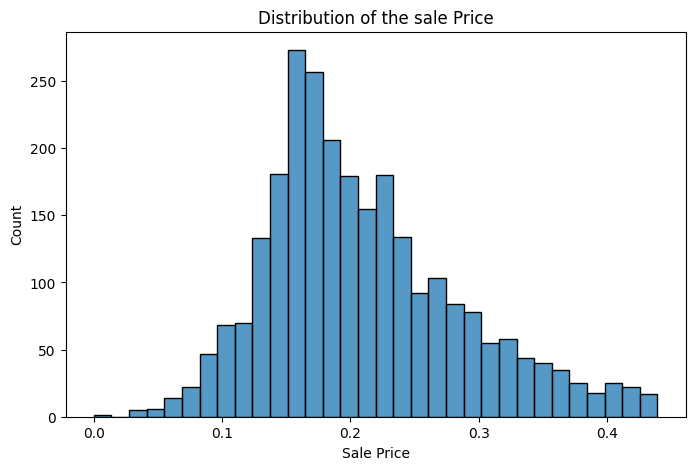

In [88]:
plt.figure(figsize=(8, 5))
sns.histplot(selected_homes["saleprice"])
plt.title("Distribution of the sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

### Observation from this histogram :

this histogram shows us how the sales prices are distributed in our dataset . As we can see here most homes are grouped in the middle price range, while there are fewer homes price appear too be at the very low or very high sale price . More or less the sales price is distributed evenly.

Boxplot : **Living Area versus Velocity Group**

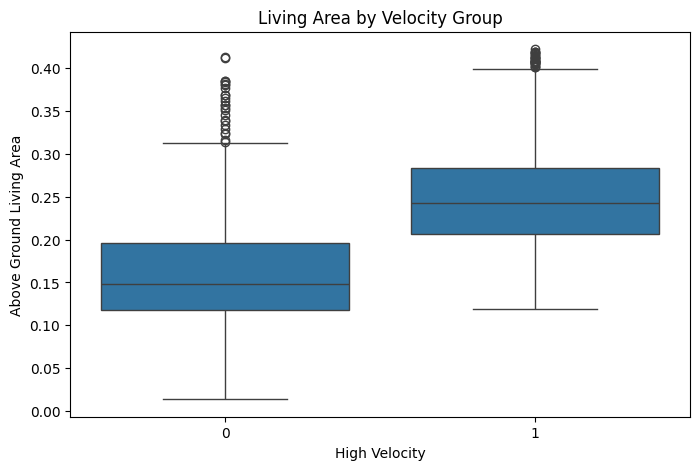

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="High-Velocity", y="grlivarea", data=selected_homes)
plt.title("Living Area by Velocity Group")
plt.xlabel("High Velocity")
plt.ylabel("Above Ground Living Area")
plt.show()

### Observation from this boxplot :

This is our boxplot which shows the comparision of above-ground living area for the two velocity groups. So in my observation , I saw that homes in the `High-Velocity = 1` group generally have a larger living area that homes in the `High-velocity = 0` group

**Boxplot**: showing the `garagecars` **number** of cars the garge can contain relation with the velocity group

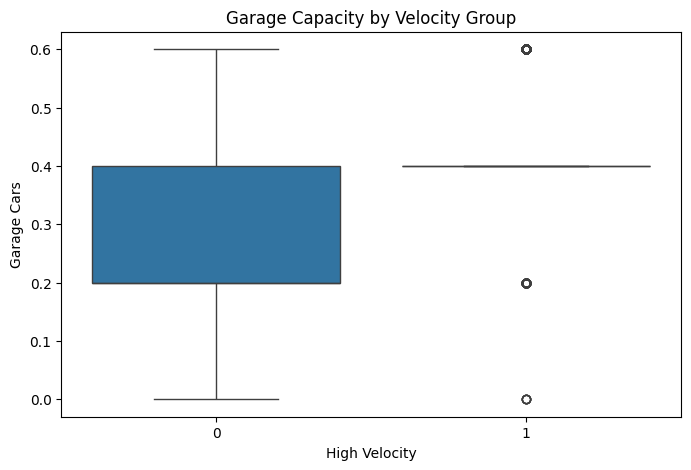

In [90]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="High-Velocity", y="garagecars", data=selected_homes)
plt.title("Garage Capacity by Velocity Group")
plt.xlabel("High Velocity")
plt.ylabel("Garage Cars")
plt.show()

**In this Boxplot I have seen that:**

homes with the group of `high- velocity = 1` tends to have slightly higher garage capacity , but I haven't seen that much strong relation.

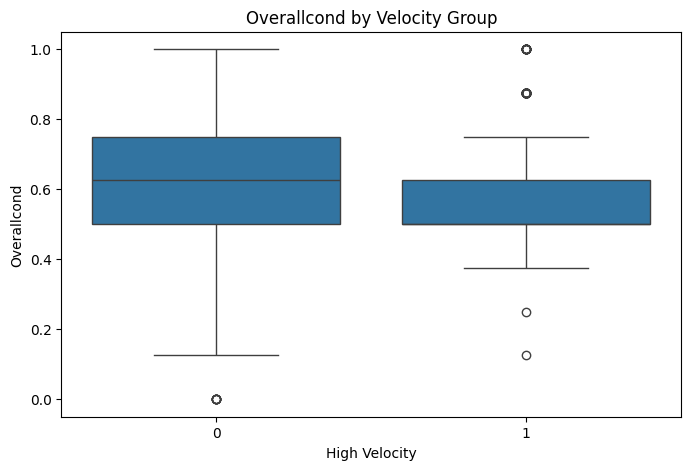

In [91]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="High-Velocity", y="overallcond", data=selected_homes)
plt.title("Overallcond by Velocity Group")
plt.xlabel("High Velocity")
plt.ylabel("Overallcond")

plt.show()

My observation for this one is that the middle value for the High-Velocity=0 group is slightly higher , but the difference is small, so the overallcondidition doesn't seen to separate the two groups clearly

## Model Selection

next task given for us is model selection for classifying our target variable
I choose logistic regression because it performs well with classification prediction and also it is easy for me to use it .

plus since our task asked us to develop more than one models for comaring and choosing the one which performed well

so for this pupose i used random forest which my favorite to use with complex relationship classification tasks .

after evaluating those two , i am going to choose the one which performed best.

### Logistic Regression

I am going to get the two variables which are the dependent `Target variable` and the Independet `features`

so the features i am going to drop the target variable which is `High-Velocity`
and for the target am going to set it as `High-Velocity`

In [92]:
selected_homes

,saleprice,overallqual,overallcond,yearbuilt,totalbsmtsf,grlivarea,fullbath,garagecars,garagearea,lotarea,mosold,yrsold,house_age,High-Velocity
0,0.272444,0.555556,0.500,0.637681,0.176759,0.249058,0.25,0.4,0.354839,0.133149,0.363636,1.0,0.362319,1
1,0.124238,0.444444,0.625,0.644928,0.144354,0.105878,0.25,0.2,0.490591,0.047118,0.454545,1.0,0.355072,0
2,0.214509,0.555556,0.625,0.623188,0.217512,0.187453,0.25,0.2,0.209677,0.058843,0.454545,1.0,0.376812,1
3,0.238626,0.444444,0.500,0.905797,0.151882,0.243971,0.50,0.4,0.323925,0.056916,0.181818,1.0,0.094203,1
4,0.246171,0.555556,0.625,0.913043,0.151555,0.239261,0.50,0.4,0.315860,0.039761,0.454545,1.0,0.086957,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2622,0.174763,0.555556,0.625,0.811594,0.164157,0.126036,0.25,0.4,0.395161,0.030551,0.181818,0.0,-0.811594,0
2623,0.159269,0.444444,0.500,0.804348,0.141408,0.107008,0.25,0.4,0.325269,0.034839,0.454545,0.0,-0.804348,0
2624,0.160616,0.444444,0.500,0.869565,0.149264,0.119819,0.25,0.0,0.000000,0.041838,0.545455,0.0,-0.869565,0
2625,0.211814,0.444444,0.500,0.739130,0.227332,0.198757,0.25,0.4,0.280914,0.039905,0.272727,0.0,-0.739130,1


In [93]:
features = selected_homes.drop(columns = ["High-Velocity", "saleprice"])

then set the target variable as `High-Velocity`

In [94]:
target = selected_homes["High-Velocity"]

let us check those two if we did it right?

In [95]:
features.head()

,overallqual,overallcond,yearbuilt,totalbsmtsf,grlivarea,fullbath,garagecars,garagearea,lotarea,mosold,yrsold,house_age
0,0.555556,0.500,0.637681,0.176759,0.249058,0.25,0.4,0.354839,0.133149,0.363636,1.0,0.362319
1,0.444444,0.625,0.644928,0.144354,0.105878,0.25,0.2,0.490591,0.047118,0.454545,1.0,0.355072
2,0.555556,0.625,0.623188,0.217512,0.187453,0.25,0.2,0.209677,0.058843,0.454545,1.0,0.376812
3,0.444444,0.500,0.905797,0.151882,0.243971,0.50,0.4,0.323925,0.056916,0.181818,1.0,0.094203
4,0.555556,0.625,0.913043,0.151555,0.239261,0.50,0.4,0.315860,0.039761,0.454545,1.0,0.086957


In [96]:
target.head()

,High-Velocity
0,1
1,0
2,1
3,1
4,1


yeah so our dependent and the independent variables are ready for our classificarion model . Let us go directly into spliting the dataset into train , test set . I am planning to use 20% of my dataset for testing my model , and 80% for the training set.

In [97]:
training_features, testing_features, training_target, testing_target = train_test_split(features, target, test_size = 0.2, random_state=42)

Let us now fit our data to the logictic regression model

In [98]:
logistic_model = LogisticRegression(max_iter = 1000)
logistic_model.fit(training_features, training_target)

LogisticRegression(max_iter=1000)

let us now predict our target using logistic_model.predict() method

In [99]:
logistic_prediction = logistic_model.predict(testing_features)

let us check our prediction array

In [100]:
logistic_prediction

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,

Now let us go to building our random forest model.

### Random Forest Model

In [101]:
forest_model = RandomForestClassifier(random_state=42)

Let us now fit our data to the random forest model

In [102]:
forest_model.fit(training_features, training_target)

RandomForestClassifier(random_state=42)

let us now predict our target using `forest_model.predict()` method

In [103]:
forest_predictions = forest_model.predict(testing_features)

let us check our prediction array

In [104]:
forest_predictions

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,

### Top 5 Important Features for predicting the `High-Velocity`

let us use random forest method called feature_importance to compare the importance of each features and sort out only the top 5 .

In [110]:
feature_importance = pd.DataFrame({
    "Feature": training_features.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(5)

,Feature,Importance
2,yearbuilt,0.185964
4,grlivarea,0.164423
0,overallqual,0.126472
5,fullbath,0.102357
8,lotarea,0.091277


As we can see here the top 5  important features are those , which are yearbuilt , grlivarea, overallqual, fullbath, and lotarea

After building the two classification model, I compare their performance to see which one is performing better for this classification task,

## Model Evaluation

### Logistic Regression Model Evaluation




First , I evaluated the logistic regression model , using the F1-Score , classification report and confusion matrix.

In [105]:
logistic_f1 = f1_score(testing_target, logistic_prediction)
print("Logistic Regression F1-Score: ", round(logistic_f1, 3))

Logistic Regression F1-Score:  0.896


In [106]:
print(classification_report(testing_target, logistic_prediction))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       256
           1       0.90      0.89      0.90       270

    accuracy                           0.89       526
   macro avg       0.89      0.89      0.89       526
weighted avg       0.89      0.89      0.89       526



It looks so good, the logistic regression model performed very well on the test data.

It reached an **F1-score of 0.914**, which shows a strong balance between precision and recall.

Looking at the classification report:
- for the High-Velocity class **0**, the model has **0.90 precision**, **0.92 recall**, and **0.91 F1-score**
- for the High-Velocity class **1**, the model has **0.92 precision**, **0.90 recall**, and **0.91 F1-score**

The overall **accuracy is 0.91**, which means the model correctly predicted about **91%** of the test cases.

Since the scores for both classes are very similar, the model appears to perform in a balanced and reliable way across the two groups.

### Random Forest Model Evaluation

Next I want to evaluate my random forest model's performance from the same metric that I evaluated my Logistic Regression Model.

In [107]:
forest_f1 = f1_score(testing_target, forest_predictions)

In [108]:
print("Random Forest F1 Score:", round(forest_f1, 3))

Random Forest F1 Score: 0.919


In [109]:
print(classification_report(testing_target, forest_predictions))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92       256
           1       0.93      0.90      0.92       270

    accuracy                           0.92       526
   macro avg       0.92      0.92      0.92       526
weighted avg       0.92      0.92      0.92       526



**Model Selection** : Between the two models , random forest performed better , so it is the best choice for this project. Because It gave a higher F1-Score and better overall result

### Business Recommendation

The operation manager can use this prediction model to help them decide on which home listing to investing describe extra marketing support or premium photography .

Here is my guideline:



*   If a home is predicted as "High-velocity" , the company should invest more like , the company can consider using premium photography or more promotion on the listing.
*   If a home is predicted as No to the "High-Velocity" , the company should choose just simple marketing plan and avoid using premium plans .

